# EDA — Proyecto STARWARS_AUTOCALLS
### Banco Imperial de Coruscant — División de Estructuración Cuantitativa

Este notebook explora las tres tablas entregadas

| Fichero | Grano | Contenido |
|---|---|---|
| `rfqs.csv` | 1 fila por solicitud de cotización (RFQ) | Términos del producto, contraparte, trader, fechas, target |
| `daily_volatility.csv` | 1 fila por subyacente y día | Volatilidad realizada 63d (panel temporal) |
| `underlyings_reference.csv` | 1 fila por subyacente | Sector y volatilidad estructural de largo plazo |


## 0. Setup

Descarga de cosas y setup de las gráficas

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)



RFQS_PATH = "../data/raw/rfqs.csv"
VOL_PATH = "../data/raw/daily_volatility.csv"
REF_PATH = "../data/raw/underlyings_reference.csv"


In [ ]:
# Función para dado un dataframe ver los nulos por columna
def missing_report(df: pd.DataFrame, name: str = "") -> pd.DataFrame:
    """Tabla de nulos: conteo, %, y dtype por columna."""
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    }).sort_values("pct_missing", ascending=False)
    if name:
        print(f"--- {name}: {df.shape[0]:,} filas x {df.shape[1]} columnas ---")
    return rep

3 FUnción para transformar las columnas dadas y el dataframe dado en una fecha
def date_cols_to_datetime(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df


## 1. Carga de datos y primer vistazo

Cargamos las tres tablas por separado (representan sistemas de origen
distintos: front-office, mercado y referencia). Antes de tocar nada,
miramos forma, tipos y primeras filas de cada una.

In [12]:
rfqs = pd.read_csv(RFQS_PATH)
vol = pd.read_csv(VOL_PATH)
ref = pd.read_csv(REF_PATH)

for name, df in [("rfqs", rfqs), ("daily_volatility", vol), ("underlyings_reference", ref)]:
    print(f"{name}: {df.shape[0]:,} filas x {df.shape[1]} columnas")


rfqs: 25,000 filas x 17 columnas
daily_volatility: 44,744 filas x 3 columnas
underlyings_reference: 14 filas x 3 columnas


In [13]:
rfqs.head()

,rfq_id,product_type,underlyings,basket_type,autocall_barrier_pct,protection_barrier_pct,no_call_period_months,observation_frequency,quoted_implied_vol,notional_credits,counterparty,trader_id,requested_date,executed,start_date,end_date,avg_duration_months
0,RFQ-000000,Kessel Run Snowball,CLNE|DRC,worst_of,1.0000,0.5424,3,Monthly,0.2455,250000,Jabba Asset Management,TRD-015,2022-09-08,False,2022-09-08,2030-01-22,NaN
1,RFQ-000001,Kessel Run Snowball,SITH|WOOK,worst_of,1.0000,0.6258,6,1Y,0.2365,100000,Corellian Capital,TRD-010,2022-06-10,False,2022-06-10,2030-08-09,NaN
2,RFQ-000002,Death Star Phoenix Note,MNDO|NABO,worst_of,1.0152,0.5899,2,1M,0.2011,100000,Nal Hutta Traders,TRD-026,2019-05-27,False,2019-05-27,2028-12-09,NaN
3,RFQ-000003,Kessel Run Snowball,TECH|SITH,worst_of,1.0000,0.5944,4,6M,0.2755,250000,Chandrila Sovereign Fund,TRD-032,2021-09-01,True,2021-09-01,2026-01-30,30.71
4,RFQ-000004,Mandalorian Twin-Win,JEDI,single,1.3149,0.7880,0,3 months,0.1266,100000,Corellian Capital,TRD-034,2023-04-06,False,2023-04-06,2026-07-13,NaN


In [14]:
rfqs.dtypes

rfq_id                        str
product_type                  str
underlyings                   str
basket_type                   str
autocall_barrier_pct      float64
protection_barrier_pct    float64
no_call_period_months       int64
observation_frequency         str
quoted_implied_vol        float64
notional_credits            int64
counterparty                  str
trader_id                     str
requested_date                str
executed                     bool
start_date                    str
end_date                      str
avg_duration_months       float64
dtype: object

In [15]:
vol.head()

,date,underlying,realized_vol_63d
0,2014-04-01,KYBR,0.194111
1,2014-04-02,KYBR,0.186989
2,2014-04-03,KYBR,0.188895
3,2014-04-04,KYBR,0.187141
4,2014-04-07,KYBR,0.195557


In [16]:
ref.head()

,underlying,sector,structural_base_vol
0,KYBR,Mineria de materiales estrategicos,0.22
1,CORL,Logistica y transporte,0.28
2,MNDO,Defensa y armamento,0.35
3,HTTX,Comercio y materias primas,0.50
4,TECH,Tecnologia y automatizacion,0.32


## 2. `rfqs.csv`

### 2.1 Duplicados y clave primaria
`rfq_id` debería identificar unívocamente cada fila.

In [17]:
print("rfq_id duplicados:", rfqs["rfq_id"].duplicated().sum())
print("Filas totalmente duplicadas:", rfqs.duplicated().sum())


rfq_id duplicados: 0
Filas totalmente duplicadas: 0


### 2.2 Nulos — vista global

Ver que valores nulos hay y en que clomnas. Sabemos que las que tienen excecuted False tienen valores nulos en avg_duration_moths

In [18]:
missing_report(rfqs, "rfqs.csv")

--- rfqs.csv: 25,000 filas x 17 columnas ---


,dtype,n_missing,pct_missing,n_unique
avg_duration_months,float64,11204,44.82,6506
rfq_id,str,0,0.00,25000
product_type,str,0,0.00,6
basket_type,str,0,0.00,2
underlyings,str,0,0.00,2043
protection_barrier_pct,float64,0,0.00,3409
no_call_period_months,int64,0,0.00,7
observation_frequency,str,0,0.00,18
autocall_barrier_pct,float64,0,0.00,3468
quoted_implied_vol,float64,0,0.00,4146


In [19]:
# Distribución de la variable que condiciona el resto
print(rfqs["executed"].value_counts(dropna=False))
print()
print(rfqs["executed"].value_counts(normalize=True, dropna=False).round(3) * 100, "%")


executed
True     13796
False    11204
Name: count, dtype: int64

executed
True     55.2
False    44.8
Name: proportion, dtype: float64 %


In [20]:
# Verificamos que la condicionalidad es exacta: start_date/end_date/avg_duration_months
# deberían ser no-nulos SIEMPRE que executed==True, y nulos SIEMPRE que executed==False.
cond_cols = ["start_date", "end_date", "avg_duration_months"]
for c in cond_cols:
    cross = pd.crosstab(rfqs["executed"], rfqs[c].isna(), rownames=["executed"], colnames=[f"{c}_isna"])
    print(cross, "\n")


start_date_isna  False
executed              
False            11204
True             13796 

end_date_isna  False
executed            
False          11204
True           13796 

avg_duration_months_isna  False  True 
executed                              
False                         0  11204
True                      13796      0 



### 2.3 Fechas

In [22]:
rfqs = date_cols_to_datetime(rfqs, ["requested_date", "start_date", "end_date"])

print("requested_date:", rfqs["requested_date"].min(), "->", rfqs["requested_date"].max())
print("start_date:    ", rfqs["start_date"].min(), "->", rfqs["start_date"].max())
print("end_date:      ", rfqs["end_date"].min(), "->", rfqs["end_date"].max())


requested_date: 2016-01-04 00:00:00 -> 2024-06-28 00:00:00
start_date:     2016-01-04 00:00:00 -> 2024-07-03 00:00:00
end_date:       2018-01-25 00:00:00 -> 2034-05-27 00:00:00


In [ ]:
# Coherencia temporal: solo tiene sentido para executed == True
ex = rfqs[rfqs["executed"] == True].copy()

lag_request_start = (ex["start_date"] - ex["requested_date"]).dt.days
nominal_maturity_months = (ex["end_date"] - ex["start_date"]).dt.days / 30.44

print("¿Algún start_date anterior a requested_date? ->", (lag_request_start < 0).sum())
print("¿Algún end_date anterior o igual a start_date? ->", (ex["end_date"] <= ex["start_date"]).sum())


Lag requested_date -> start_date (días): describe
count    13796.000000
mean         2.519208
std          1.708430
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
dtype: float64

¿Algún start_date anterior a requested_date? -> 0
¿Algún end_date anterior o igual a start_date? -> 0

Vencimiento nominal (meses) - describe:
count    13796.000000
mean        71.946805
std         27.720359
min         24.014455
25%         48.028909
50%         71.681997
75%         95.992116
max        119.973719
dtype: float64


TODO EN ORDEN

### 2.5 Target vs vencimiento nominal — ¿cuándo se cancela anticipadamente?

Ver si se cancelo antes de que venciera el producto

In [25]:
ex["duration_ratio"] = ex["avg_duration_months"] / ex["nominal_maturity_months"]

print(ex["duration_ratio"].describe())

# Regla simple de referencia (no definitiva) para clasificar en 'llegó a vencimiento' vs 'autocall anticipado'
ex["reached_maturity_approx"] = ex["duration_ratio"] >= 0.98
print()
print(ex["reached_maturity_approx"].value_counts(normalize=True).round(3) * 100, "%")


count    13796.000000
mean         0.578784
std          0.244935
min          0.003273
25%          0.400197
50%          0.579233
75%          0.777537
max          1.202640
Name: duration_ratio, dtype: float64

reached_maturity_approx
False    96.8
True      3.2
Name: proportion, dtype: float64 %


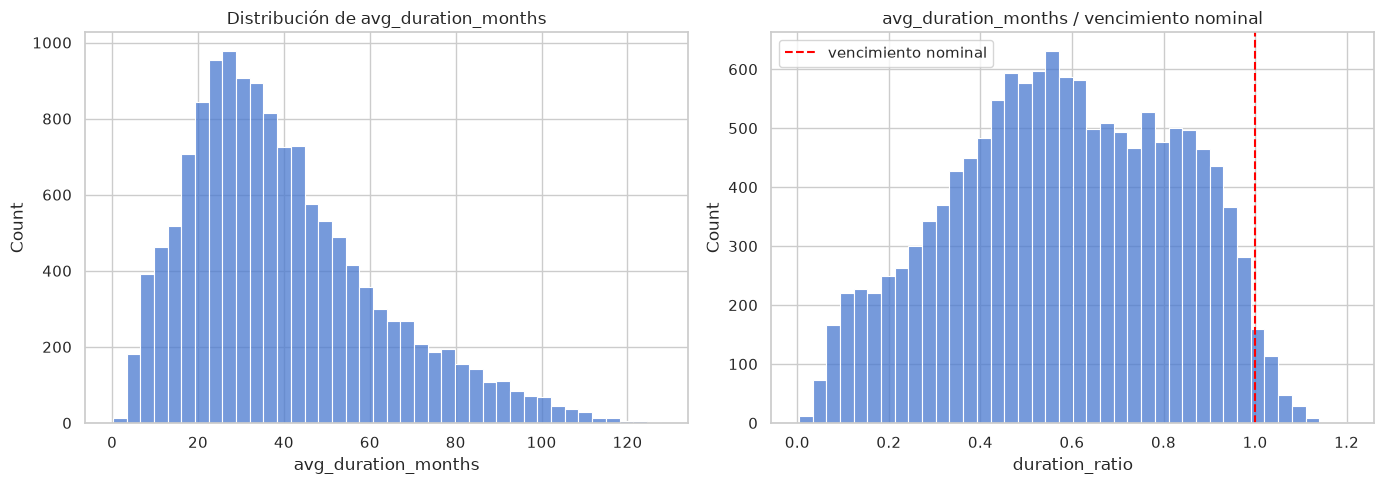

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(ex["avg_duration_months"], bins=40, ax=ax[0])
ax[0].set_title("Distribución de avg_duration_months")

sns.histplot(ex["duration_ratio"].clip(upper=1.2), bins=40, ax=ax[1])
ax[1].axvline(1.0, color="red", linestyle="--", label="vencimiento nominal")
ax[1].set_title("avg_duration_months / vencimiento nominal")
ax[1].legend()
plt.tight_layout()
plt.show()


### 2.7 Variables categóricas

Miramos lasa proporciones de las variables categóricas que hay

In [28]:
cat_cols = ["product_type", "basket_type", "observation_frequency", "counterparty", "trader_id"]
for c in cat_cols:
    print(f"--- {c} ({rfqs[c].nunique()} valores únicos) ---")
    print(rfqs[c].value_counts(dropna=False))
    print()


--- product_type (6 valores únicos) ---
product_type
Holocron Reverse Convertible    4245
Mandalorian Twin-Win            4216
Wretched Hive Digital           4167
Sith Eternal Snowball           4160
Death Star Phoenix Note         4148
Kessel Run Snowball             4064
Name: count, dtype: int64

--- basket_type (2 valores únicos) ---
basket_type
worst_of    16539
single       8461
Name: count, dtype: int64

--- observation_frequency (18 valores únicos) ---
observation_frequency
1M            6174
3M            5298
6M            3618
2M            1995
1Y            1601
1D             711
Monthly        670
mensual        667
1 month        658
M              651
Quarterly      576
trimestral     570
Q              566
3 months       559
12M            191
Y              175
Annual         164
anual          156
Name: count, dtype: int64

--- counterparty (8 valores únicos) ---
counterparty
Corellian Capital           3195
Kamino Cloning Trust        3160
Banco de Coruscant      

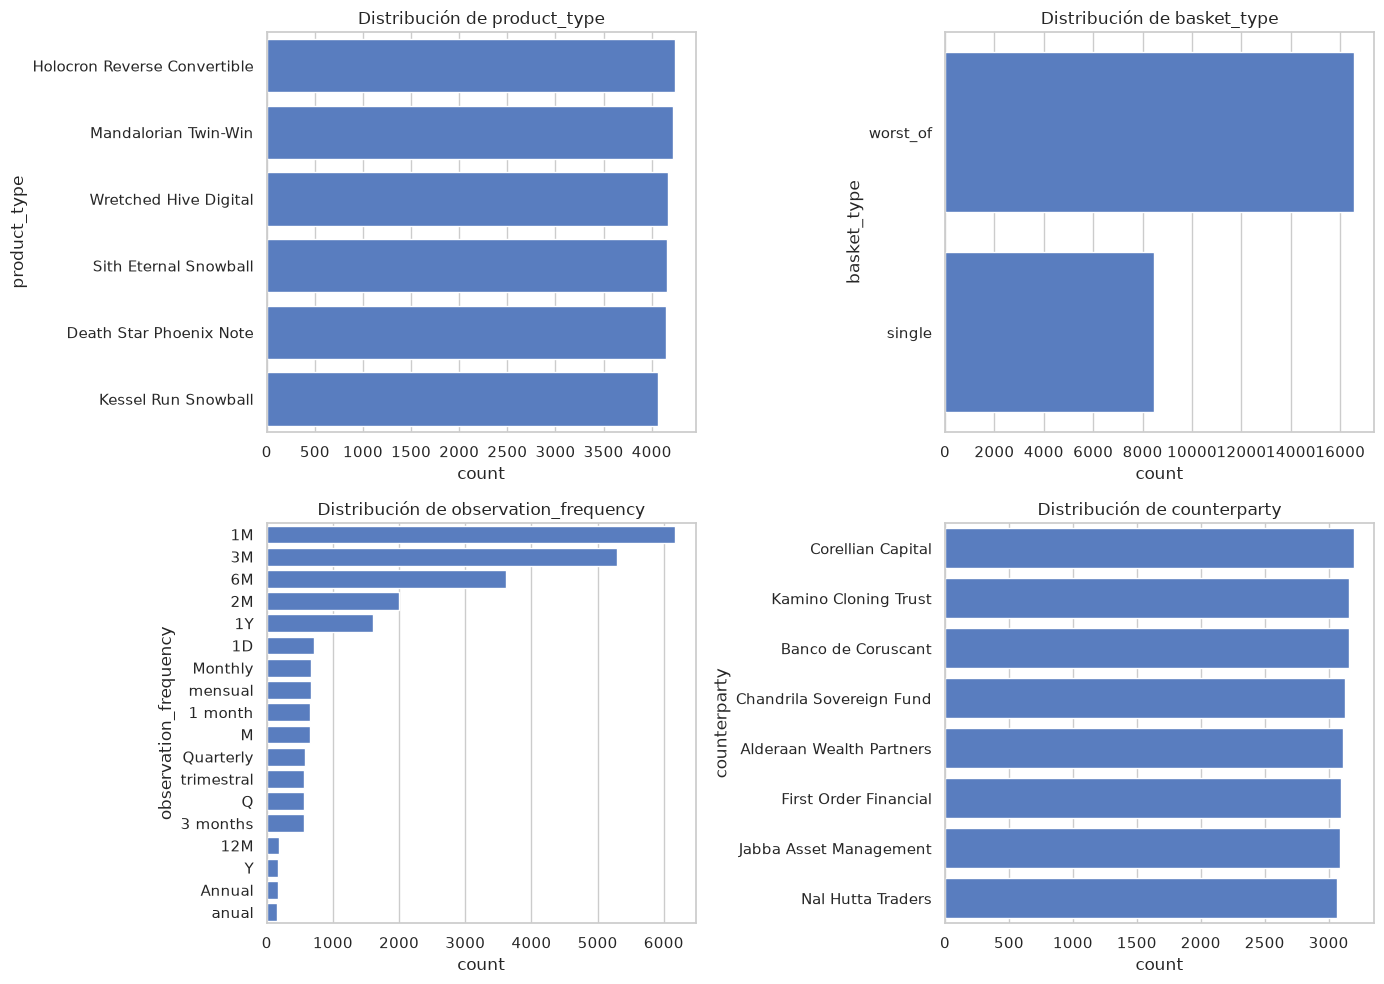

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, c in zip(axes.flat, ["product_type", "basket_type", "observation_frequency", "counterparty"]):
    order = rfqs[c].value_counts().index
    sns.countplot(data=rfqs, y=c, order=order, ax=ax)
    ax.set_title(f"Distribución de {c}")
plt.tight_layout()
plt.show()


**No hay consistencia en los nombres de  Observation Frequency, necesitamos un proceso para poder unificarlo**

### 2.8 Underlyings

In [30]:
rfqs["underlyings_list"] = rfqs["underlyings"].str.split("|")
rfqs["basket_size"] = rfqs["underlyings_list"].apply(len)

print("Tamaño de cesta - distribución:")
print(rfqs["basket_size"].value_counts().sort_index())
print()

# ¿basket_type == 'single' implica siempre basket_size == 1?
print(pd.crosstab(rfqs["basket_type"], rfqs["basket_size"]))


Tamaño de cesta - distribución:
basket_size
1     8461
2    12379
3     4160
Name: count, dtype: int64

basket_size     1      2     3
basket_type                   
single       8461      0     0
worst_of        0  12379  4160


In [31]:
all_underlyings = rfqs["underlyings_list"].explode()
underlying_counts = all_underlyings.value_counts()
print(f"Universo de subyacentes usados en rfqs.csv: {underlying_counts.shape[0]} tickers")
underlying_counts.head(20)


Universo de subyacentes usados en rfqs.csv: 14 tickers


underlyings_list
JEDI    3377
CORL    3328
TECH    3322
BSKR    3317
NABO    3290
WOOK    3286
HTTX    3273
POBK    3239
SITH    3232
REBL    3231
CLNE    3228
DRC     3221
MNDO    3215
KYBR    3140
Name: count, dtype: int64

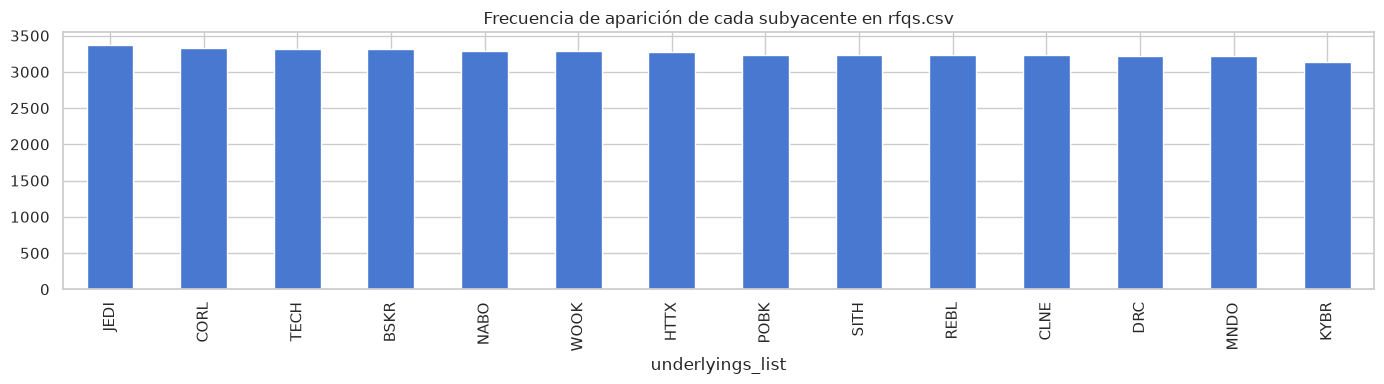

In [32]:
underlying_counts.plot(kind="bar", figsize=(14, 4), title="Frecuencia de aparición de cada subyacente en rfqs.csv")
plt.tight_layout()
plt.show()


### 2.9 Variables numéricas de contrato

`autocall_barrier_pct`, `protection_barrier_pct`, `no_call_period_months`,
`quoted_implied_vol`, `notional_credits`. Miramos rango, outliers y valores
fuera de lo físicamente razonable (p.ej. barreras negativas o > 200%,
periodos de no-call negativos, vol implícita negativa o extrema).

In [33]:
num_cols = ["autocall_barrier_pct", "protection_barrier_pct", "no_call_period_months",
            "quoted_implied_vol", "notional_credits"]
rfqs[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
autocall_barrier_pct,25000.0,1.139004,1.472571e-01,0.9500,1.0000,1.15270,1.2761,1.400000e+00
protection_barrier_pct,25000.0,0.663538,9.647306e-02,0.5000,0.6000,0.62250,0.7609,8.500000e-01
no_call_period_months,25000.0,1.480160,2.016732e+00,0.0000,0.0000,0.00000,3.0000,6.000000e+00
quoted_implied_vol,25000.0,0.278661,8.905546e-02,0.0936,0.2177,0.27425,0.3305,5.997000e-01
notional_credits,25000.0,676412.000000,1.695565e+06,100000.0000,100000.0000,250000.00000,500000.0000,2.000000e+07


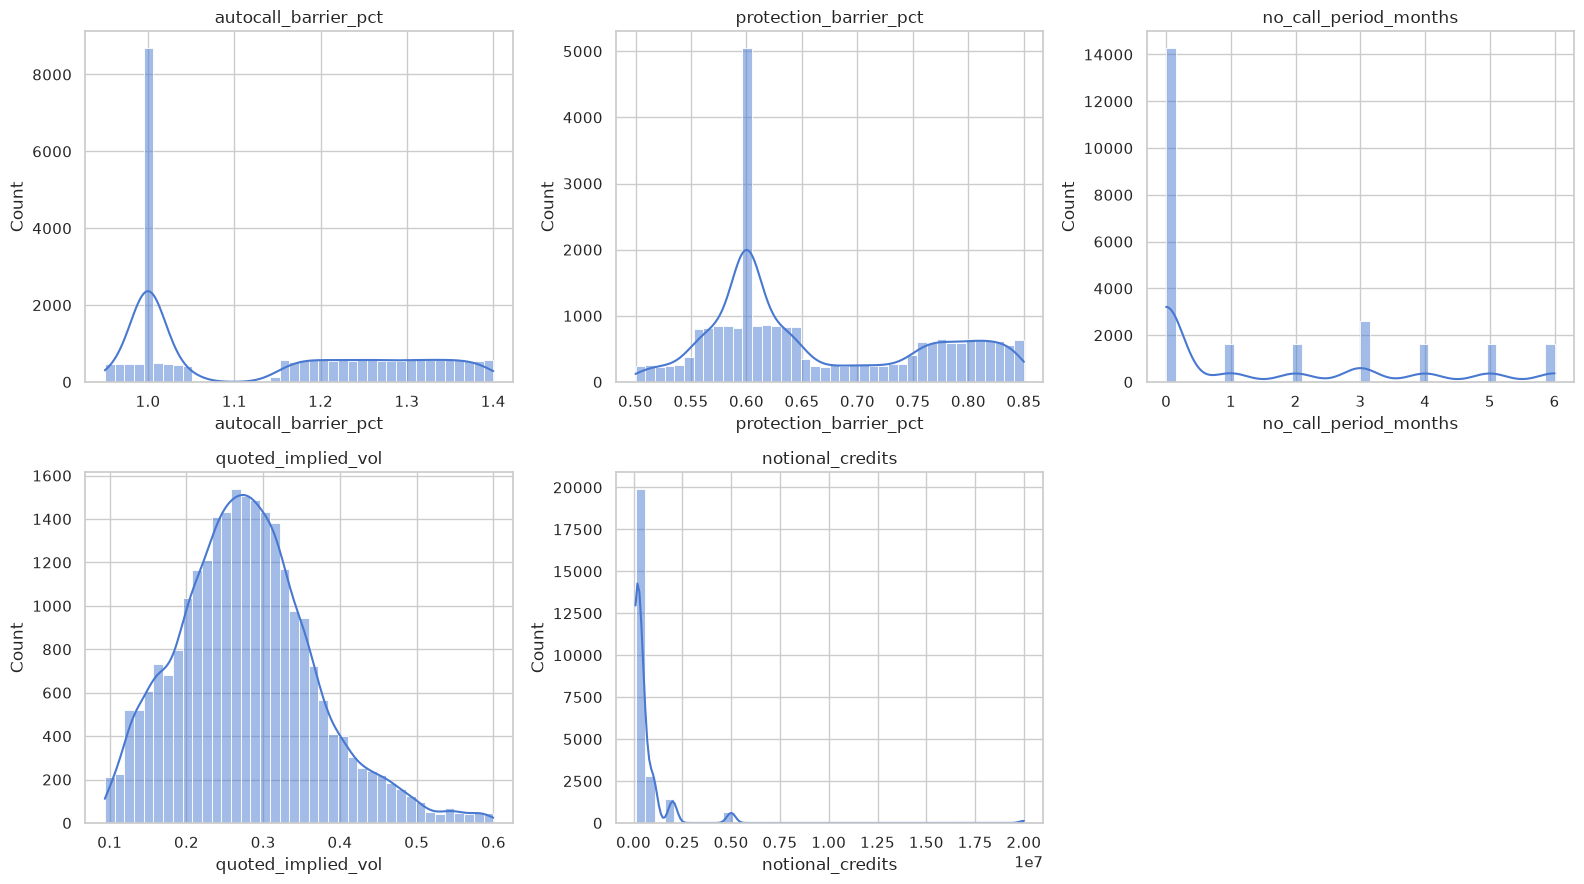

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(rfqs[c].dropna(), bins=40, ax=ax, kde=True)
    ax.set_title(c)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


In [35]:
# Chequeos de sanidad — ajustar rangos si el negocio define otros límites válidos
sanity_checks = {
    "autocall_barrier_pct fuera de [0, 2]": ~rfqs["autocall_barrier_pct"].between(0, 2),
    "protection_barrier_pct fuera de [0, 2]": ~rfqs["protection_barrier_pct"].between(0, 2),
    "no_call_period_months negativo": rfqs["no_call_period_months"] < 0,
    "quoted_implied_vol <= 0": rfqs["quoted_implied_vol"] <= 0,
    "notional_credits <= 0": rfqs["notional_credits"] <= 0,
}
for label, mask in sanity_checks.items():
    n = mask.sum()
    print(f"{label}: {n} filas" + (f"  <-- REVISAR" if n else ""))


autocall_barrier_pct fuera de [0, 2]: 0 filas
protection_barrier_pct fuera de [0, 2]: 0 filas
no_call_period_months negativo: 0 filas
quoted_implied_vol <= 0: 0 filas
notional_credits <= 0: 0 filas


In [36]:
# no_call_period_months vs vencimiento nominal: el periodo de no-call nunca debería
# superar el vencimiento nominal del producto (solo aplica a executed==True)
ex["no_call_period_months"] = rfqs.loc[ex.index, "no_call_period_months"]
violations = ex["no_call_period_months"] > ex["nominal_maturity_months"]
print(f"RFQs con no_call_period_months > vencimiento nominal: {violations.sum()} ({violations.mean()*100:.2f}%)")


RFQs con no_call_period_months > vencimiento nominal: 0 (0.00%)


Aquí hemos visto que todos los datos estan en orden pero que algunas distribuciones si que son raras y alomejor tenemos que tomar una decisión si transformarlas o pasarlas a categóricas

## 3. `daily_volatility.csv` — panel de mercado

In [38]:
vol = date_cols_to_datetime(vol, ["date"])
missing_report(vol, "daily_volatility.csv")


--- daily_volatility.csv: 44,744 filas x 3 columnas ---


,dtype,n_missing,pct_missing,n_unique
date,datetime64[us],0,0.0,3196
underlying,str,0,0.0,14
realized_vol_63d,float64,0,0.0,44744


In [39]:
print("Rango de fechas:", vol["date"].min(), "->", vol["date"].max())
print("Nº de subyacentes distintos:", vol["underlying"].nunique())
print("Nº de fechas distintas:", vol["date"].nunique())
print()
print("Duplicados (date, underlying):", vol.duplicated(subset=["date", "underlying"]).sum())


Rango de fechas: 2014-04-01 00:00:00 -> 2026-06-30 00:00:00
Nº de subyacentes distintos: 14
Nº de fechas distintas: 3196

Duplicados (date, underlying): 0


In [40]:
# Cobertura por subyacente: nº de observaciones y primer/última fecha
coverage = vol.groupby("underlying")["date"].agg(["min", "max", "count"]).sort_values("count")
coverage.columns = ["first_date", "last_date", "n_obs"]
coverage


,first_date,last_date,n_obs
underlying,,,
BSKR,2014-04-01,2026-06-30,3196
CLNE,2014-04-01,2026-06-30,3196
CORL,2014-04-01,2026-06-30,3196
DRC,2014-04-01,2026-06-30,3196
HTTX,2014-04-01,2026-06-30,3196
JEDI,2014-04-01,2026-06-30,3196
KYBR,2014-04-01,2026-06-30,3196
MNDO,2014-04-01,2026-06-30,3196
NABO,2014-04-01,2026-06-30,3196


In [41]:
# Huecos de calendario: para cada subyacente, ¿hay días hábiles faltantes dentro de su rango?
gap_summary = {}
for u, g in vol.groupby("underlying"):
    full_range = pd.bdate_range(g["date"].min(), g["date"].max())
    missing_days = full_range.difference(g["date"])
    gap_summary[u] = len(missing_days)

gap_summary = pd.Series(gap_summary, name="missing_business_days").sort_values(ascending=False)
gap_summary.head(20)


BSKR    0
CLNE    0
CORL    0
DRC     0
HTTX    0
JEDI    0
KYBR    0
MNDO    0
NABO    0
POBK    0
REBL    0
SITH    0
TECH    0
WOOK    0
Name: missing_business_days, dtype: int64

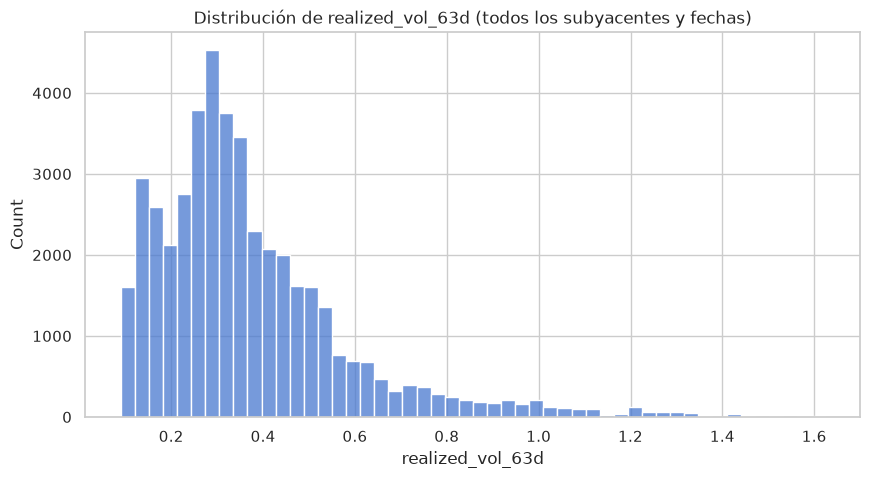

count    44744.000000
mean         0.370341
std          0.212618
min          0.089770
25%          0.234484
50%          0.322039
75%          0.451927
max          1.623879
Name: realized_vol_63d, dtype: float64

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(vol["realized_vol_63d"], bins=50, ax=ax)
ax.set_title("Distribución de realized_vol_63d (todos los subyacentes y fechas)")
plt.show()

vol["realized_vol_63d"].describe()


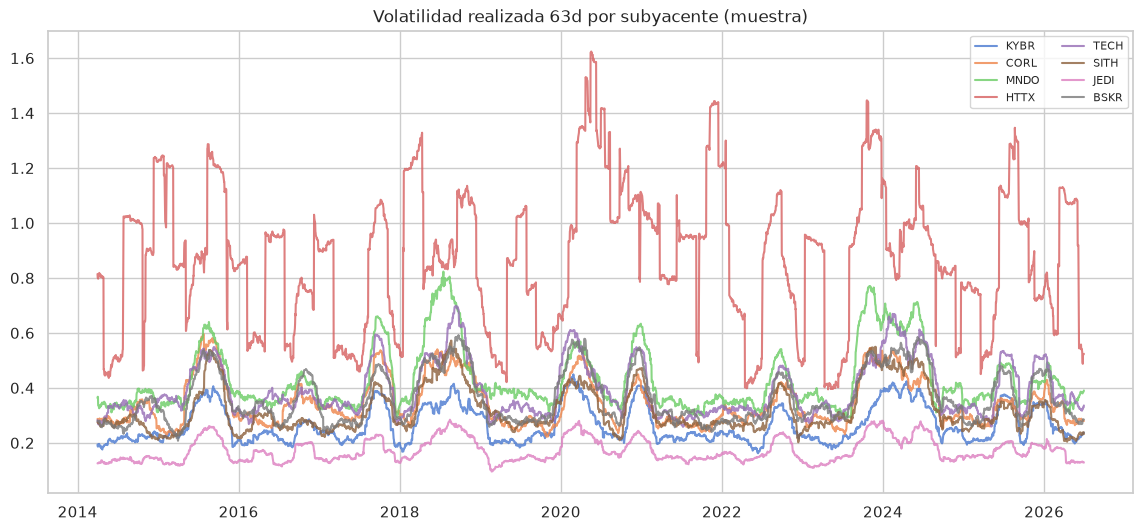

In [43]:
# Serie temporal por subyacente (muestra de hasta 8 tickers para no saturar el gráfico)
sample_tickers = vol["underlying"].drop_duplicates().head(8)
fig, ax = plt.subplots(figsize=(14, 6))
for t in sample_tickers:
    sub = vol[vol["underlying"] == t]
    ax.plot(sub["date"], sub["realized_vol_63d"], label=t, alpha=0.8)
ax.set_title("Volatilidad realizada 63d por subyacente (muestra)")
ax.legend(ncol=2, fontsize=8)
plt.show()


Todo en orden y bien

## 4. `underlyings_reference.csv` — tabla estática

In [44]:
missing_report(ref, "underlyings_reference.csv")

--- underlyings_reference.csv: 14 filas x 3 columnas ---


,dtype,n_missing,pct_missing,n_unique
underlying,str,0,0.0,14
sector,str,0,0.0,14
structural_base_vol,float64,0,0.0,14


In [45]:
print("underlying duplicados:", ref["underlying"].duplicated().sum())
print()
print("Distribución por sector:")
print(ref["sector"].value_counts(dropna=False))


underlying duplicados: 0

Distribución por sector:
sector
Mineria de materiales estrategicos    1
Logistica y transporte                1
Defensa y armamento                   1
Comercio y materias primas            1
Tecnologia y automatizacion           1
Energia e infraestructuras            1
Gestion patrimonial                   1
Metales y aleaciones                  1
Ocio y entretenimiento                1
Agricultura y biotecnologia           1
Renta fija especulativa               1
Manufactura                           1
Servicios y personal                  1
Consumo y distribucion                1
Name: count, dtype: int64


## 5. Cruces entre tablas — cobertura y claves

Vemos si hay alguna fecha que no cuadre

In [47]:
rfq_underlyings_universe = set(all_underlyings.dropna().unique())
vol_universe = set(vol["underlying"].unique())
ref_universe = set(ref["underlying"].unique())

print(f"Subyacentes en rfqs.csv:                {len(rfq_underlyings_universe)}")
print(f"Subyacentes en daily_volatility.csv:     {len(vol_universe)}")
print(f"Subyacentes en underlyings_reference.csv:{len(ref_universe)}")
print()
print("En rfqs pero NO en daily_volatility:", sorted(rfq_underlyings_universe - vol_universe))
print("En rfqs pero NO en underlyings_reference:", sorted(rfq_underlyings_universe - ref_universe))
print()
print("En daily_volatility pero NO en rfqs (subyacentes 'huérfanos', normal si el universo de mercado es más amplio):")
print(sorted(vol_universe - rfq_underlyings_universe))


Subyacentes en rfqs.csv:                14
Subyacentes en daily_volatility.csv:     14
Subyacentes en underlyings_reference.csv:14

En rfqs pero NO en daily_volatility: []
En rfqs pero NO en underlyings_reference: []

En daily_volatility pero NO en rfqs (subyacentes 'huérfanos', normal si el universo de mercado es más amplio):
[]


In [48]:
# Cobertura temporal: ¿daily_volatility cubre las fechas de requested_date / start_date de rfqs?
print("Rango daily_volatility:", vol['date'].min(), "->", vol['date'].max())
print("Rango requested_date en rfqs:", rfqs['requested_date'].min(), "->", rfqs['requested_date'].max())
print("Rango start_date en rfqs (executed):", ex['start_date'].min(), "->", ex['start_date'].max())

rfqs_before_vol = (rfqs["requested_date"] < vol["date"].min()).sum()
rfqs_after_vol = (rfqs["requested_date"] > vol["date"].max()).sum()
print(f"\nRFQs con requested_date anterior al histórico de vol: {rfqs_before_vol}")
print(f"RFQs con requested_date posterior al histórico de vol: {rfqs_after_vol}")


Rango daily_volatility: 2014-04-01 00:00:00 -> 2026-06-30 00:00:00
Rango requested_date en rfqs: 2016-01-04 00:00:00 -> 2024-06-28 00:00:00
Rango start_date en rfqs (executed): 2016-01-04 00:00:00 -> 2024-07-03 00:00:00

RFQs con requested_date anterior al histórico de vol: 0
RFQs con requested_date posterior al histórico de vol: 0


## 6. Relación de variables con el target (`avg_duration_months`)

Ver correlaciones y si hay algun caso de diferencias evidentes, para tomar una decisión en caso de que haga falta

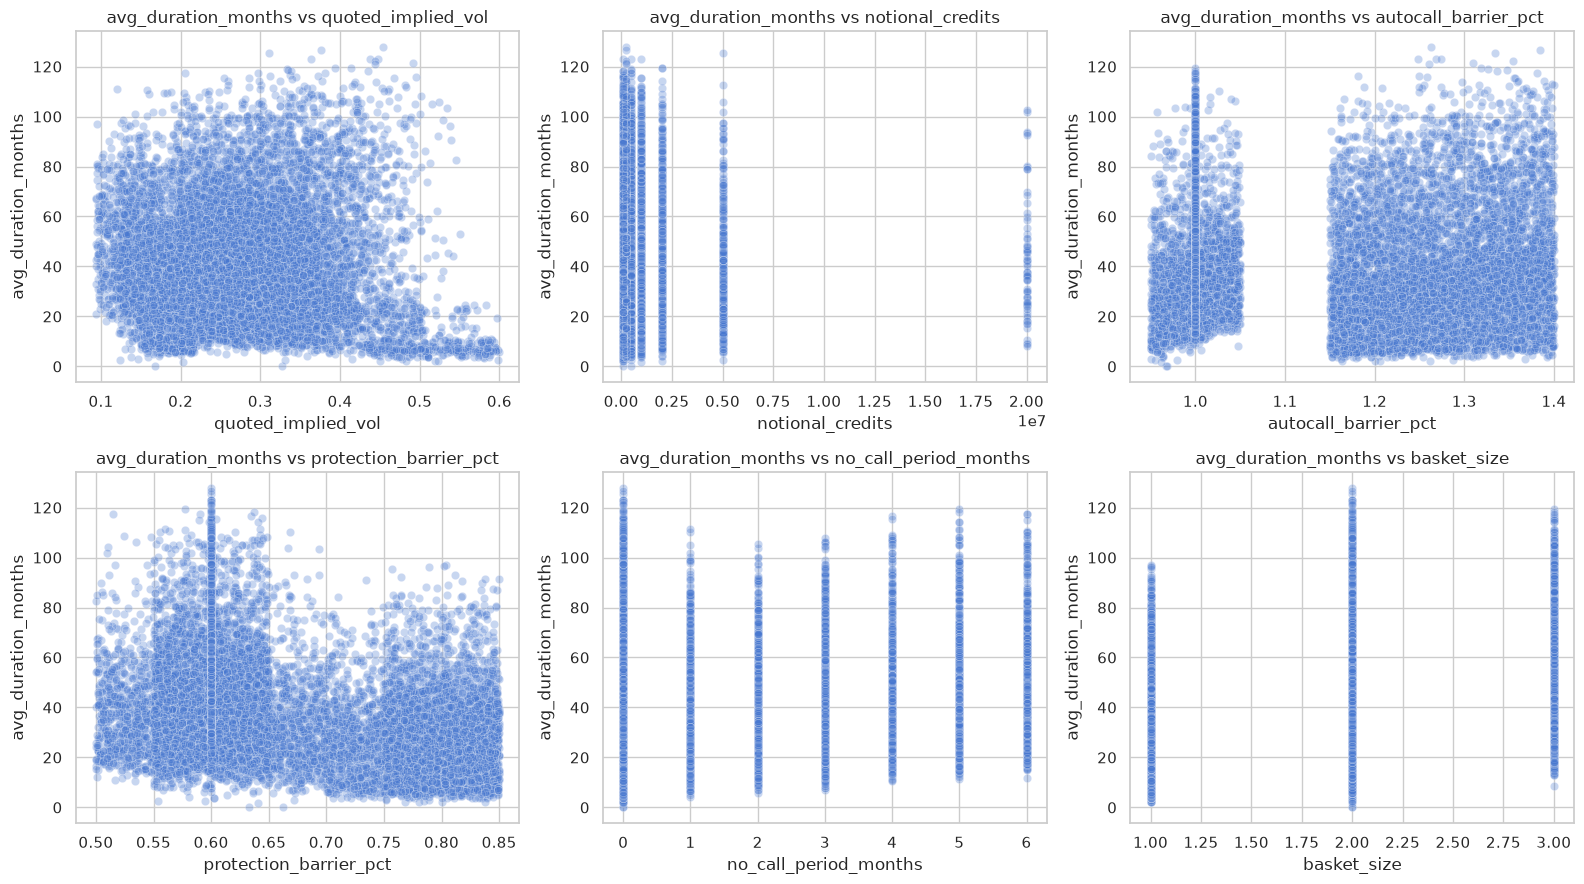

In [49]:
ex_full = ex.merge(rfqs[["rfq_id"] + cat_cols + num_cols + ["basket_size"]], on="rfq_id", suffixes=("", "_dup"))
# nos quedamos con una copia limpia de columnas relevantes
plot_num_cols = ["quoted_implied_vol", "notional_credits", "autocall_barrier_pct",
                  "protection_barrier_pct", "no_call_period_months", "basket_size"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, plot_num_cols):
    sns.scatterplot(data=ex_full, x=c, y="avg_duration_months", alpha=0.3, ax=ax)
    ax.set_title(f"avg_duration_months vs {c}")
plt.tight_layout()
plt.show()


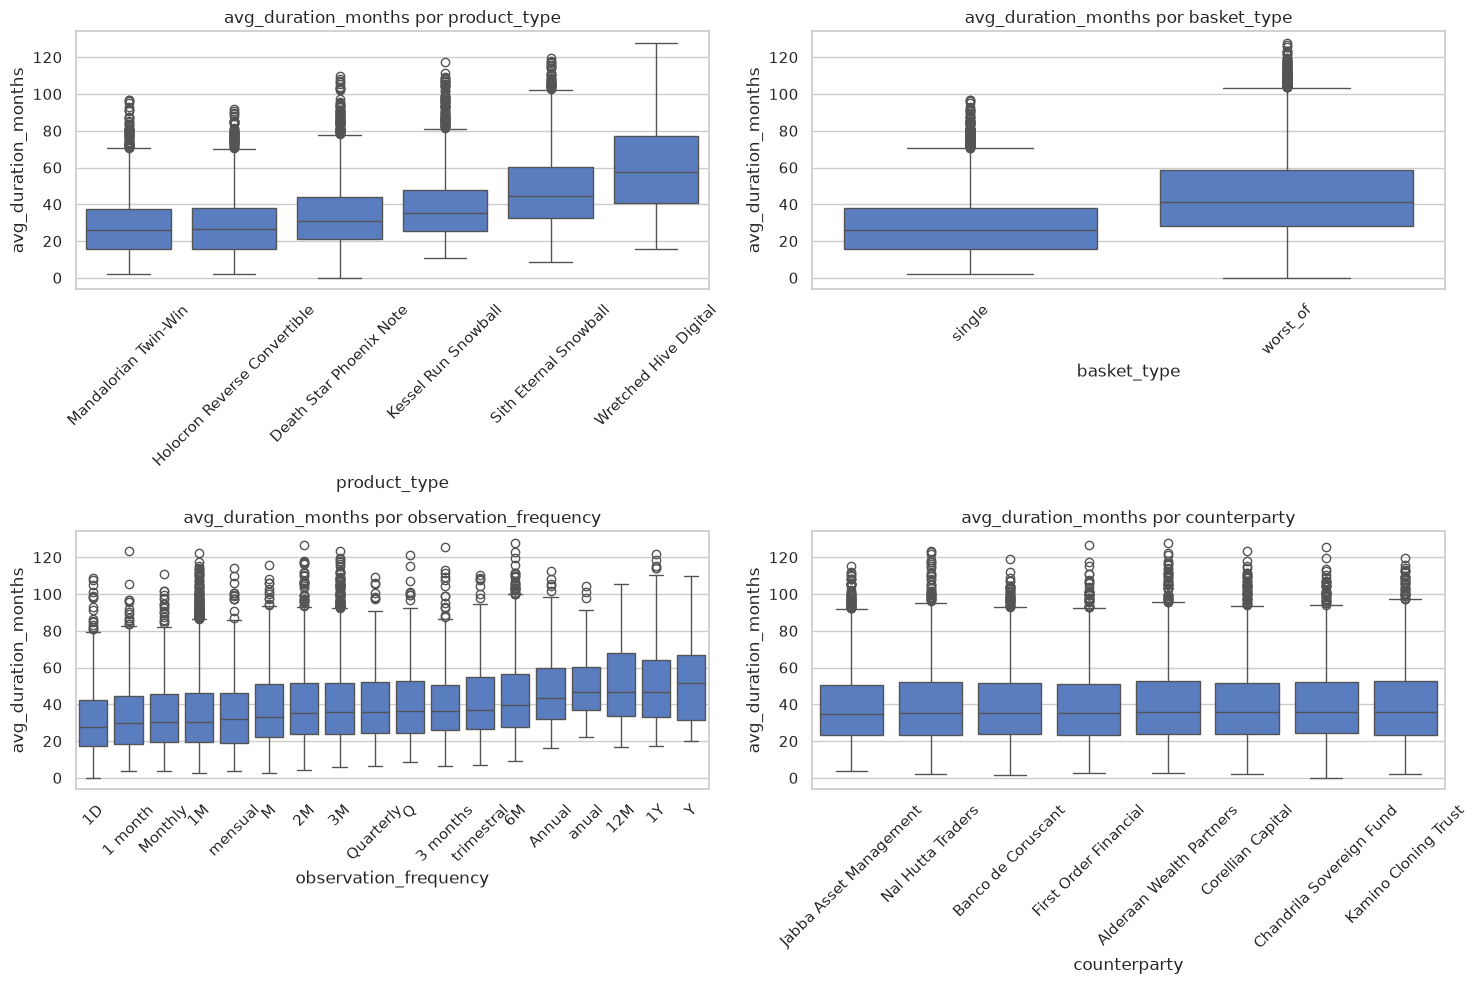

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, c in zip(axes.flat, ["product_type", "basket_type", "observation_frequency", "counterparty"]):
    order = ex_full.groupby(c)["avg_duration_months"].median().sort_values().index
    sns.boxplot(data=ex_full, x=c, y="avg_duration_months", order=order, ax=ax)
    ax.set_title(f"avg_duration_months por {c}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


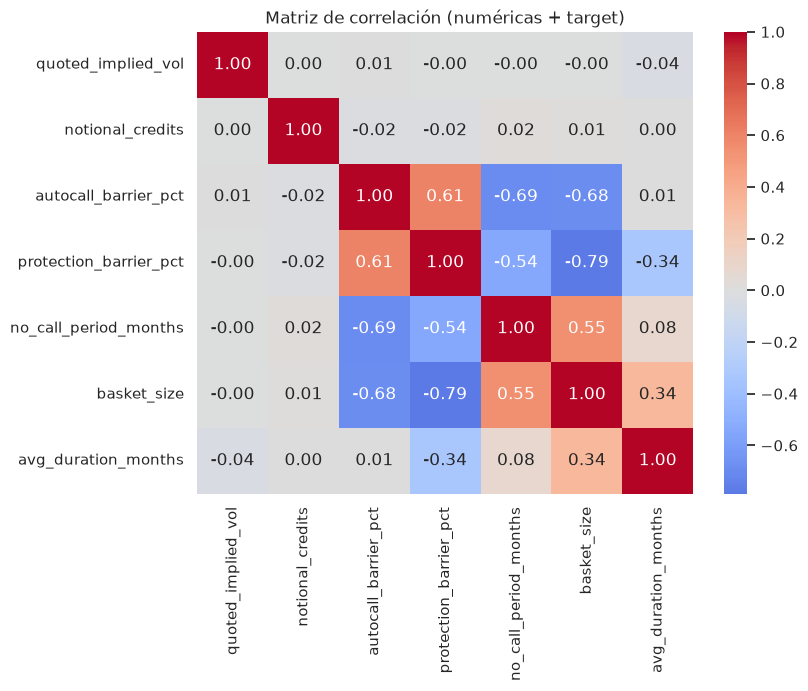

In [51]:
# Correlación entre numéricas + target
corr_cols = plot_num_cols + ["avg_duration_months"]
corr = ex_full[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación (numéricas + target)")
plt.show()
